**Transformation de la DB des urls en dataframe pandas**

In [112]:
import sqlite3
import pandas as pd
import os

db_path = "..\\data\\speeches.db"
conn=sqlite3.connect(db_path)
df1=pd.read_sql_query("Select * from Speeches",conn)
conn.close()

In [113]:
df1.head(3)

,id,url,title,date,nbr_sentences,nbr_words,nbr_seconds,categories
0,1,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses Service Members...,"October 5, 2025",693,6902,2636,"[""Armed Forces"", ""Waterway and Maritime Transp..."
1,2,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses Military Leader...,"September 30, 2025",1031,12529,4261,"[""Politics"", ""Military Equipment"", ""Government..."
2,3,https://rollcall.com/factbase/trump/transcript...,Speech: JD Vance Discusses Tax Policy and Publ...,"September 24, 2025",,,,"[""Government"", ""Crime"", ""Police"", ""Law Enforce..."


In [114]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885 entries, 0 to 884
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             885 non-null    int64 
 1   url            885 non-null    object
 2   title          885 non-null    object
 3   date           885 non-null    object
 4   nbr_sentences  885 non-null    object
 5   nbr_words      885 non-null    object
 6   nbr_seconds    885 non-null    object
 7   categories     885 non-null    object
dtypes: int64(1), object(7)
memory usage: 55.4+ KB


### Convertion of some variables into numeric/datetime

In [115]:
df1["nbr_words"]=pd.to_numeric(df1["nbr_words"], errors= "coerce",downcast="integer")
df1["nbr_sentences"]=pd.to_numeric(df1["nbr_sentences"], errors="coerce", downcast="integer")
df1["nbr_seconds"]=pd.to_numeric(df1["nbr_seconds"], errors="coerce", downcast="integer")

df1["date"]=pd.to_datetime(df1["date"], errors="coerce")

### Checking of the database and treatment of missing value

In [116]:
df1.isna().sum().sort_values(ascending=False)*100/df1.shape[0]  # sort by percentage of missing values

date             2.372881
nbr_seconds      2.372881
nbr_sentences    0.677966
nbr_words        0.677966
title            0.000000
url              0.000000
id               0.000000
categories       0.000000
dtype: float64

In [117]:
df1.fillna({"nbr_sentences" : df1["nbr_sentences"].mean(),          # fill missing value by the mean 
            "nbr_seconds": df1["nbr_seconds"].mean(),
            "nbr_words": df1["nbr_words"].mean()
}, inplace=True)                                            

### Some basis statistics 

In [118]:
df1.columns

Index(['id', 'url', 'title', 'date', 'nbr_sentences', 'nbr_words',
       'nbr_seconds', 'categories'],
      dtype='object')

In [119]:
df1[["nbr_sentences","nbr_words","nbr_seconds" ]].describe().round(2)

,nbr_sentences,nbr_words,nbr_seconds
count,885.00,885.00,885.00
mean,769.85,7915.07,3241.95
std,438.84,4273.45,1500.80
min,1.00,3.00,1.00
25%,422.00,4721.00,2192.00
50%,765.00,7761.00,3190.00
75%,1092.00,10832.00,4310.00
max,2285.00,28090.00,7295.00


### Wordcloud of categories

In [120]:
df1["categories"].head(5)

0    ["Armed Forces", "Waterway and Maritime Transp...
1    ["Politics", "Military Equipment", "Government...
2    ["Government", "Crime", "Police", "Law Enforce...
3    ["Economy, Business and Finance", "Crime", "In...
4    ["Crime", "Religion", "Crime, Law and Justice"...
Name: categories, dtype: object

In [121]:
# Creating of new dataframe with each single categorie

import ast
df1['categories'] = df1['categories'].apply(ast.literal_eval)  
df_exploded = df1.explode('categories').reset_index(drop=True)     # Explode to have single categorie instead of list

df_exploded["categories"] 

0                          Armed Forces
1       Waterway and Maritime Transport
2                              Politics
3                    Military Equipment
4         Economy, Business and Finance
                     ...               
4387      International (Foreign) Trade
4388                       Human Rights
4389                           Politics
4390      Economy, Business and Finance
4391          Construction and Property
Name: categories, Length: 4392, dtype: object

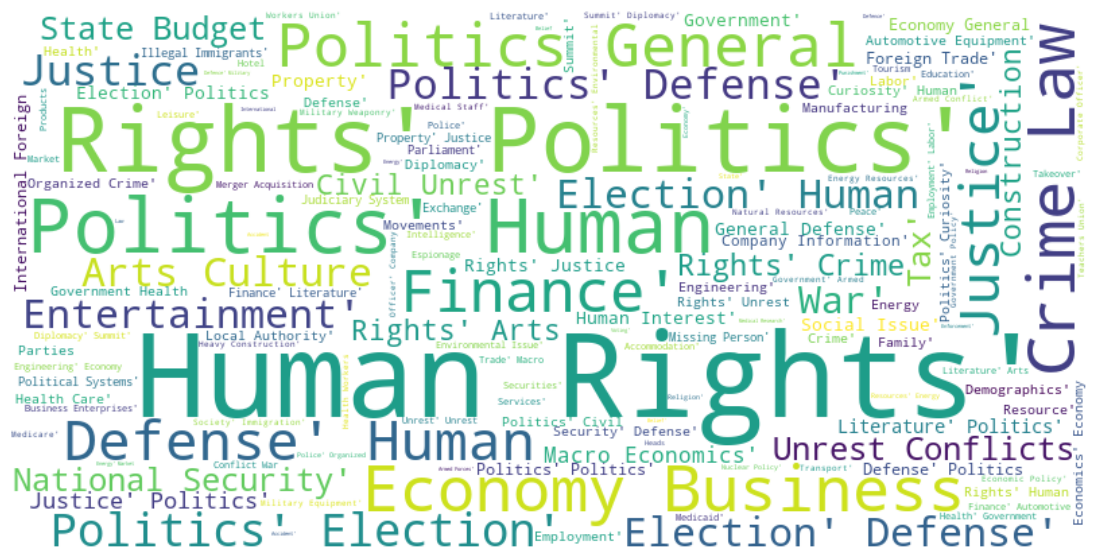

In [122]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df1['categories'].dropna().astype(str))

mwe_list = ["human rights", "foreign policy", "climate change"]
for mwe in mwe_list:
    text = text.replace(mwe, mwe.replace(" ", "_"))

wordcloud = WordCloud(width=800, height=400, collocations=True, background_color="white").generate(text)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


### Percentage of each categorie

In [127]:
df_exploded["categories"].value_counts().sort_values(ascending=False)*100/df_exploded.shape[0]

categories
Politics                      19.034608
Human Rights                  15.163934
Defense                        9.198543
Election                       6.238616
Crime, Law and Justice         4.007286
                                ...    
Monument and Heritage Site     0.022769
International Law              0.022769
Disaster and Accident          0.022769
Transport Accident             0.022769
Road Accident                  0.022769
Name: count, Length: 158, dtype: float64